# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

**Key questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding**

In this stage, we load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [ ]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

In [ ]:
# Load the dataset


In [ ]:
df = pd.read_csv('data/health_data.csv')

#### **1.1.1** Check the first few entries

In [ ]:
# Check the first few entries
display(df.head())

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant

In [ ]:
# Remove irrelevant columns like unique identifiers or index
df = df.drop(columns=['Unnamed: 0', 'id'])
display(df.head())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.3** Inspect the shape of the dataset

In [ ]:
# Inspect the shape of the dataset
df.shape

(70000, 12)

#### **1.1.4** Inspect the different columns in the dataset

In [ ]:
# Inspect the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


Check the summary of the dataset

In [ ]:
# Check the summary of the dataset
display(df.describe())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


## **2. Data Cleaning**

### **2.1 Identify and handle redundant or invalid/illogical physiological values**

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [ ]:
# Check the statistical summary of the data
display(df.describe())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [ ]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc



Remove rows with ap-hi > 300 or ap-lo < 30

In [ ]:
print(f"Number of rows with ap_hi > 300 or ap_lo < 30: {df[(df['ap_hi'] > 300) | (df['ap_lo'] < 30)].shape[0]}")

Number of rows with ap_hi > 300 or ap_lo < 30: 86


Only minority number compared to 70,000 total, these can be considered as outliers confidently, hence removing them won't have big impact downstream

In [ ]:
df = df[~((df['ap_hi'] > 300) | (df['ap_lo'] < 30))]
print(f"New shape of the DataFrame after removing outliers: {df.shape}")

New shape of the DataFrame after removing outliers: (69914, 12)


Handle rows with features that should not have 0 value (e.g. cholesterol, gluc)

In [ ]:
# Check distinct values for cholesterol and gluc
print(f"Distinct values for cholesterol: {df['cholesterol'].nunique()}")
print(f"Distinct values for gluc: {df['gluc'].nunique()}")

Distinct values for cholesterol: 3
Distinct values for gluc: 3


In [ ]:
print("Value counts for cholesterol:")
print(df['cholesterol'].value_counts())
print("\nValue counts for gluc:")
print(df['gluc'].value_counts())

Value counts for cholesterol:
cholesterol
0    52322
1     9536
2     8056
Name: count, dtype: int64

Value counts for gluc:
gluc
0    59400
2     5327
1     5187
Name: count, dtype: int64


So good thing that there are no additional value undefined, just misalign in labelling. We can interpret as below:

cholesterol:
*   0: normal
*   1: above normal
*   2: well above normal

gluc:
*   0: normal
*   1: above normal
*   2: well above normal


#### **2.1.3** Modify the representation of patient age and height

In [ ]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context

Modify age from days to years

In [ ]:
# Current days divided by 365.25 (accounting for leap year) would give the age in years, round up to the nearest whole number

In [ ]:
df['age_years'] = (df['age'] / 365.25).round().astype(int)
display(df.head())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0,50
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1,55
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1,52
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1,48
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0,48


In [ ]:
display(df.describe())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000,69914.000000
mean,19469.367409,0.349587,164.360586,74.210778,126.689676,96.705982,0.366851,0.226578,0.088208,0.053780,0.803630,0.499657,53.304574
std,2467.099337,0.476843,8.203158,14.396412,18.180403,188.571371,0.680244,0.572392,0.283600,0.225585,0.397254,0.500003,6.759719
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,17665.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,23713.000000,1.000000,250.000000,200.000000,240.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,65.000000


Modify height from cm to m

In [ ]:
df['height_meters'] = df['height'] / 100
display(df.head())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,height_meters
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0,50,1.68
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1,55,1.56
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1,52,1.65
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1,48,1.69
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0,48,1.56


### **2.2 Fix DataTypes**

#### **2.2.1** Review and fix the data types of all columns

Ensuring the columns accurately reflect the nature of the data

In [ ]:
# Fix DataTypes of the categorical columns with incorrect DataTypes
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("Categorical columns converted to 'category' data type.")

Categorical columns converted to 'category' data type.


In [ ]:
# Check the final data types post conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69914 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            69914 non-null  float64 
 1   gender         69914 non-null  category
 2   height         69914 non-null  float64 
 3   weight         69914 non-null  float64 
 4   ap_hi          69914 non-null  float64 
 5   ap_lo          69914 non-null  float64 
 6   cholesterol    69914 non-null  category
 7   gluc           69914 non-null  category
 8   smoke          69914 non-null  category
 9   alco           69914 non-null  category
 10  active         69914 non-null  category
 11  cardio         69914 non-null  category
 12  age_years      69914 non-null  int64   
 13  height_meters  69914 non-null  float64 
dtypes: category(7), float64(6), int64(1)
memory usage: 4.7 MB


## **3. Exploratory Data Analysis**

### **3.1 Perform univariate analysis**

#### **3.1.1** Visualise the numerical featuresVisualise the distribution of numerical features using appropriate plots to understand their characteristics.

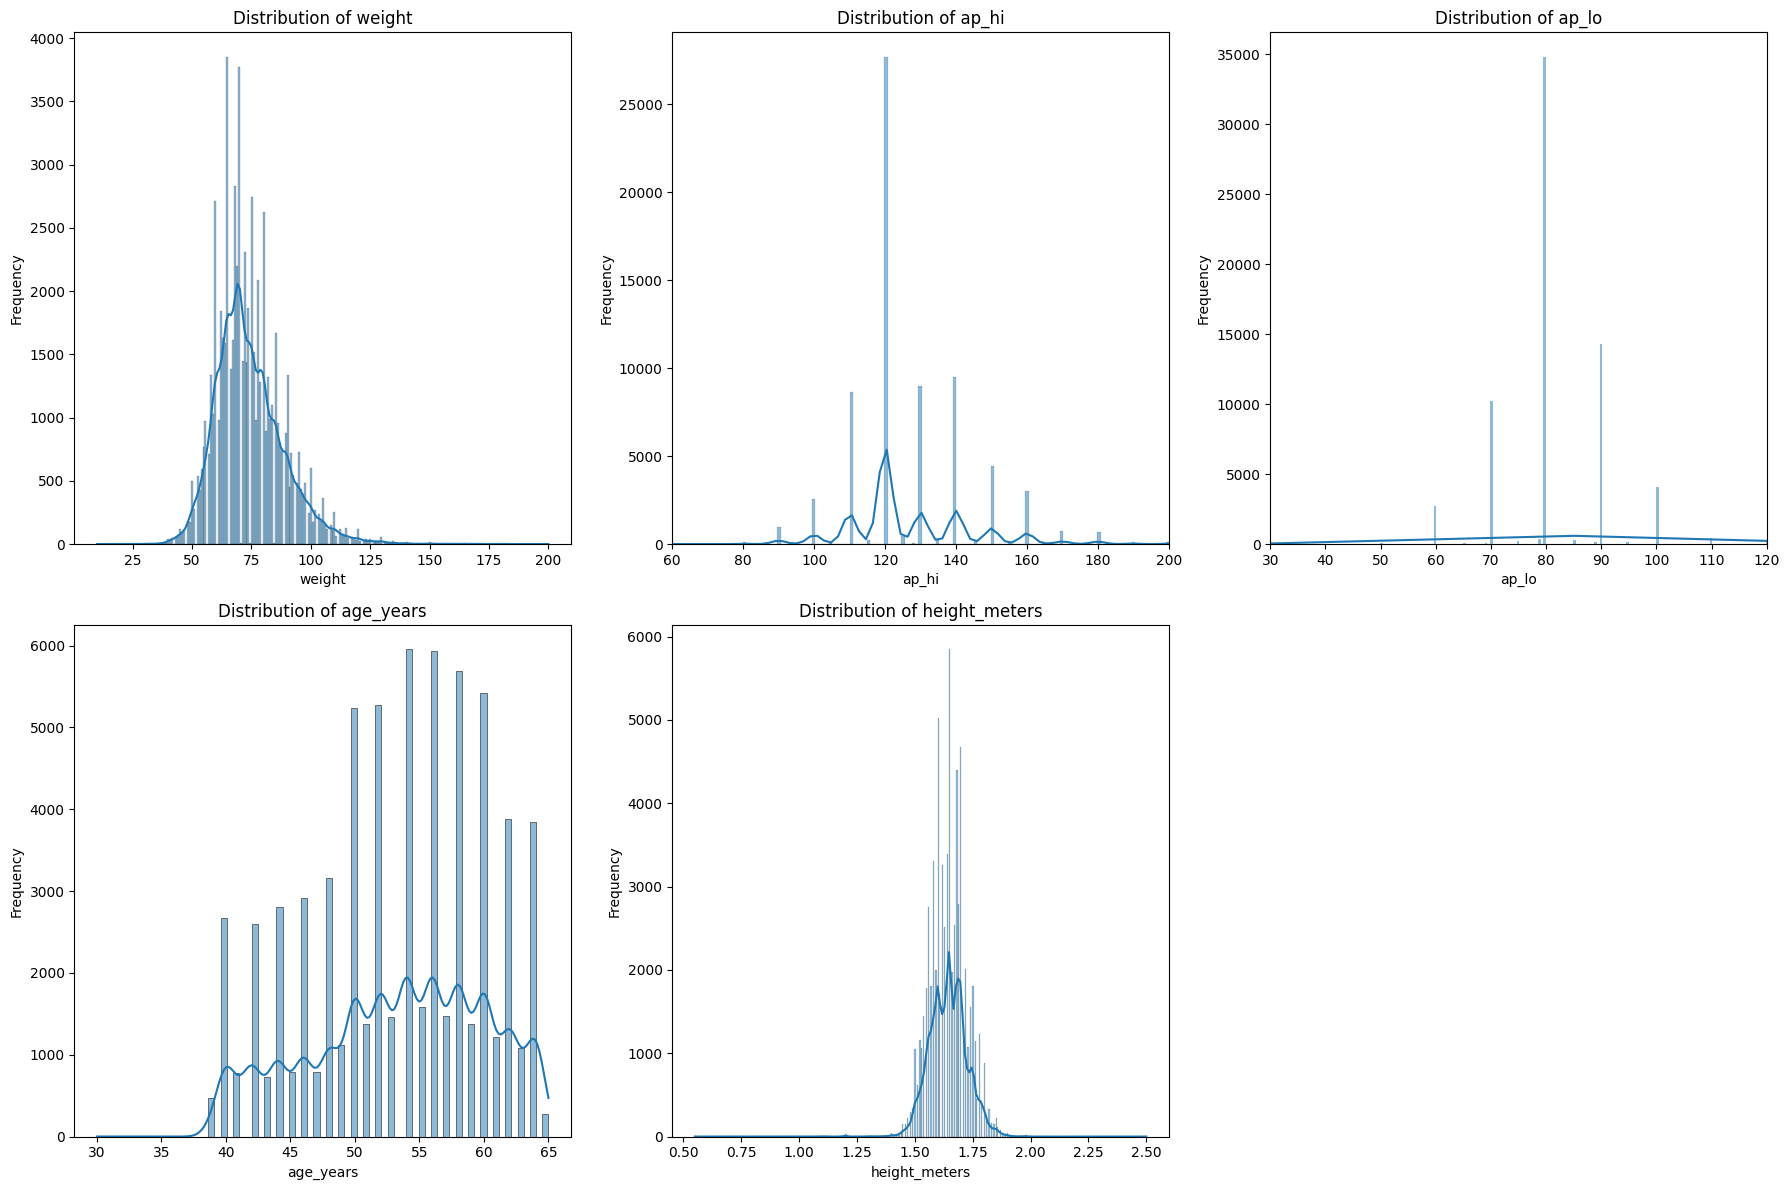

In [ ]:
# Plot all the numerical columns to understand their distribution
numerical_cols_to_plot = ['weight', 'ap_hi', 'ap_lo', 'age_years', 'height_meters']

plt.figure(figsize=(18, 12)) # Increase figure size for better readability
for i, col in enumerate(numerical_cols_to_plot):
    plt.subplot(2, 3, i + 1)  # Adjust subplot grid to 2 rows, 3 columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Set xlim for blood pressure columns for better readability
    if col == 'ap_hi':
        plt.xlim(60, 200) # Common physiological range for systolic blood pressure
    elif col == 'ap_lo':
        plt.xlim(30, 120) # Common physiological range for diastolic blood pressure

plt.tight_layout()
plt.show()

#### **3.1.2** Visualise the categorical featuresVisualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

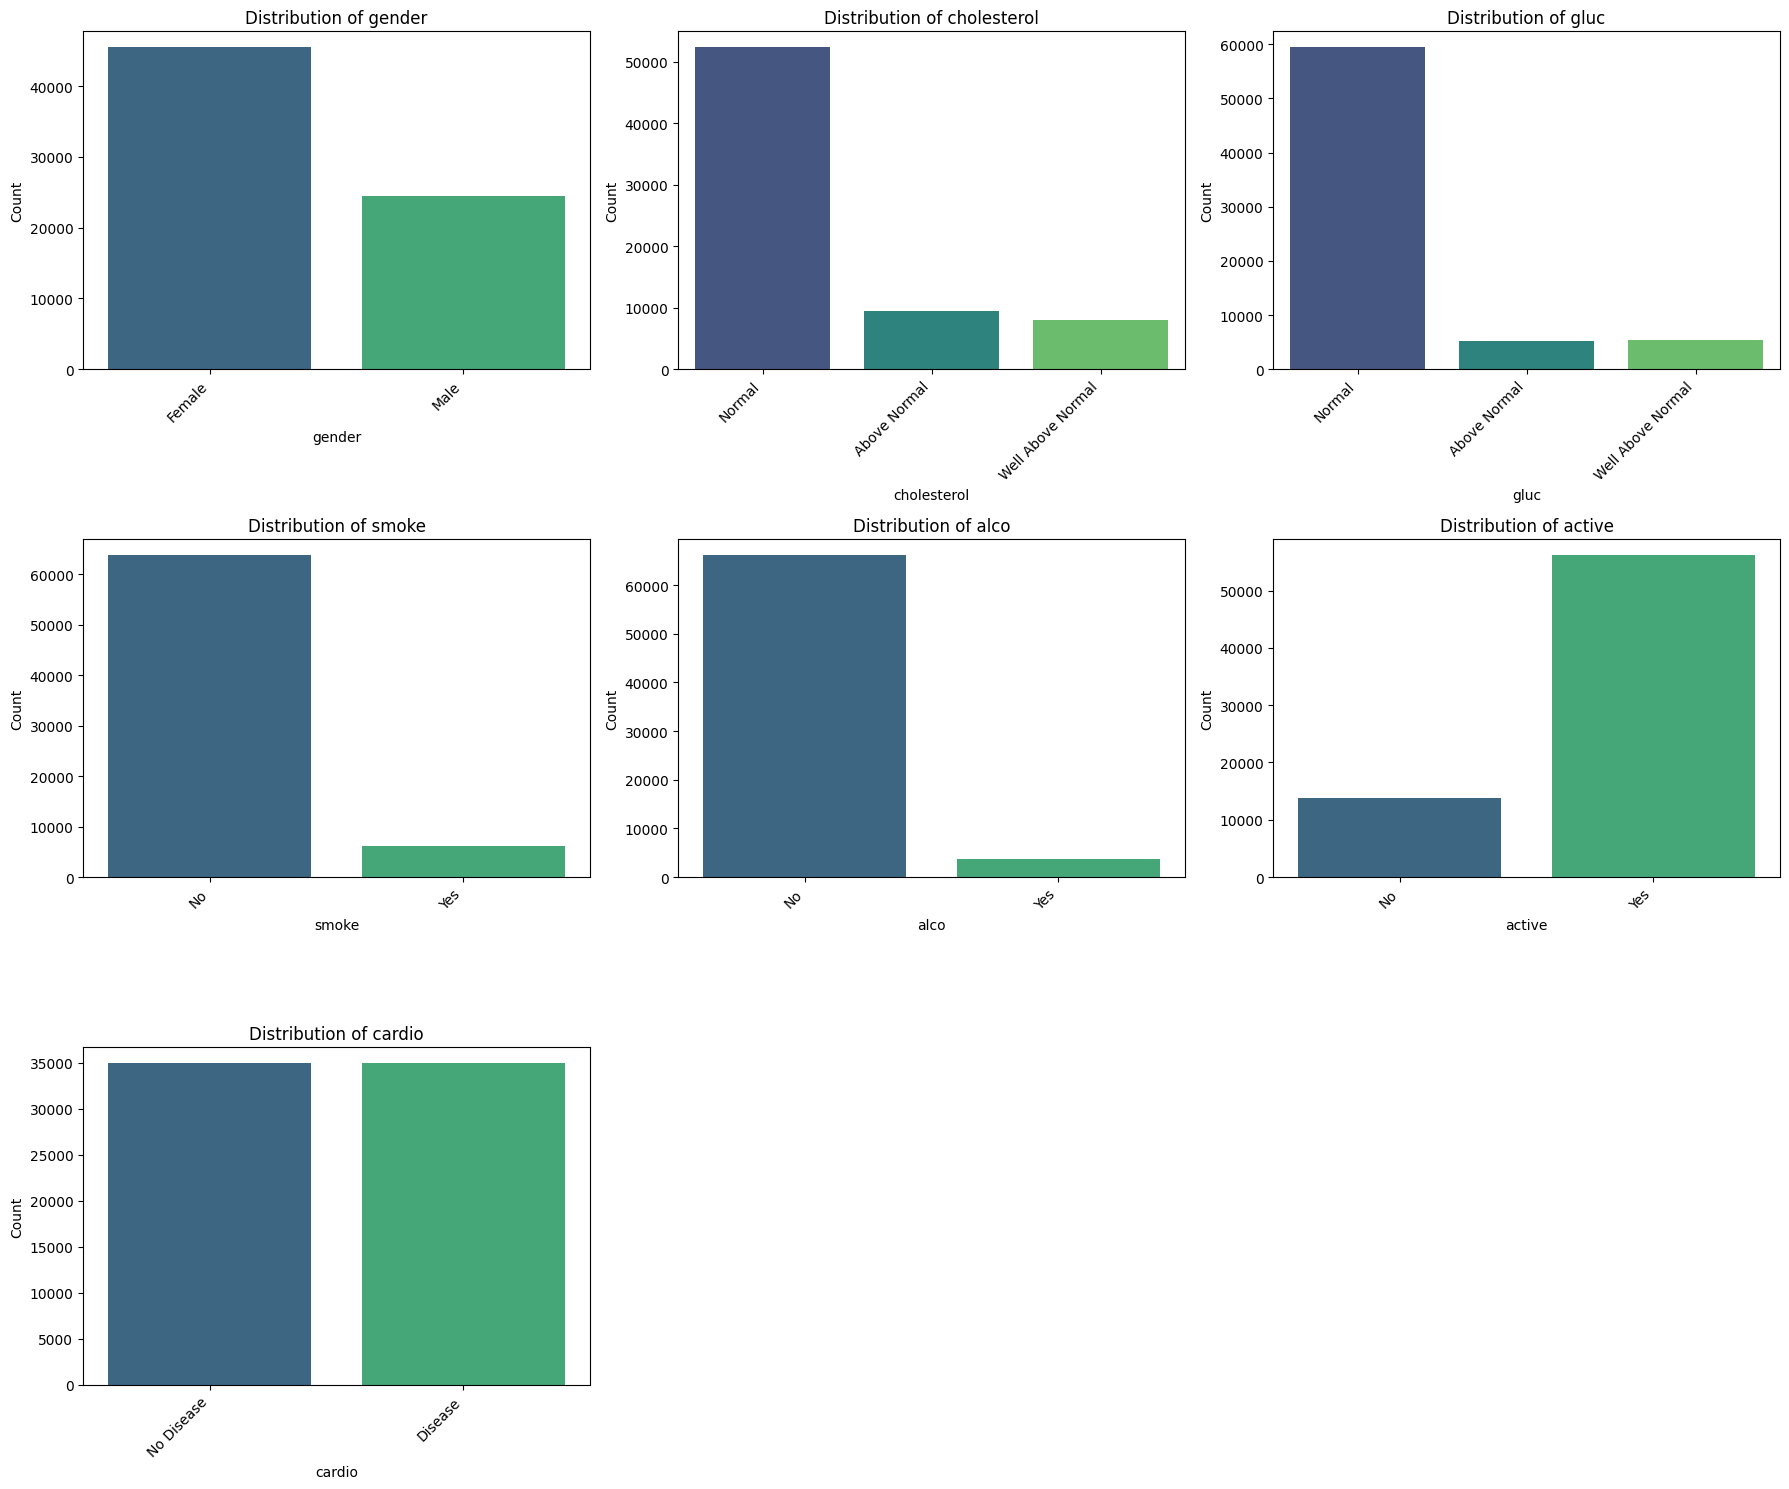

In [ ]:
# Define a mapping for the categorical labels
label_maps = {
    'gender': {0: 'Female', 1: 'Male'},
    'cholesterol': {0: 'Normal', 1: 'Above Normal', 2: 'Well Above Normal'},
    'gluc': {0: 'Normal', 1: 'Above Normal', 2: 'Well Above Normal'},
    'smoke': {0: 'No', 1: 'Yes'},
    'alco': {0: 'No', 1: 'Yes'},
    'active': {0: 'No', 1: 'Yes'},
    'cardio': {0: 'No Disease', 1: 'Disease'}
}

# Select categorical columns that have been converted to 'category' dtype
categorical_cols = df.select_dtypes(include='category').columns.tolist()

plt.figure(figsize=(18, 15)) # Adjust figure size for better readability
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed, 3 rows, 3 columns

    # Apply mapping if available for the column
    if col in label_maps:
        # Map values to descriptive labels and ensure order for plotting
        mapped_data = df[col].map(label_maps[col])
        sns.countplot(x=mapped_data, palette='viridis', order=list(label_maps[col].values()))
    else:
        sns.countplot(x=df[col], palette='viridis')

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout()
plt.show()

#### **3.1.3** Check class distribution of the target feature

In [ ]:
# Class distribution of positive and negative classes


In [ ]:
print(df['cardio'].value_counts())
print(f"\nPercentage of patients with CVD: {round(df['cardio'].value_counts(normalize=True)[1]*100, 2)}%")
print(f"Percentage of patients without CVD: {round(df['cardio'].value_counts(normalize=True)[0]*100, 2)}%")

cardio
0    34981
1    34933
Name: count, dtype: int64

Percentage of patients with CVD: 49.97%
Percentage of patients without CVD: 50.03%


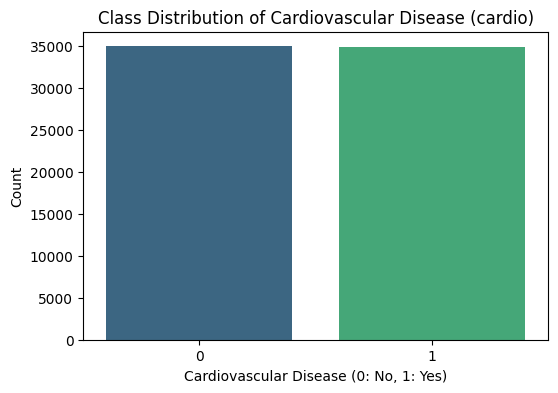

In [ ]:
fig = plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df, palette='viridis')
plt.title('Class Distribution of Cardiovascular Disease (cardio)')
plt.xlabel('Cardiovascular Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

### **3.2 Perform correlation analysis**Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships

#### **3.2.1** Visualise the correlation among numerical features

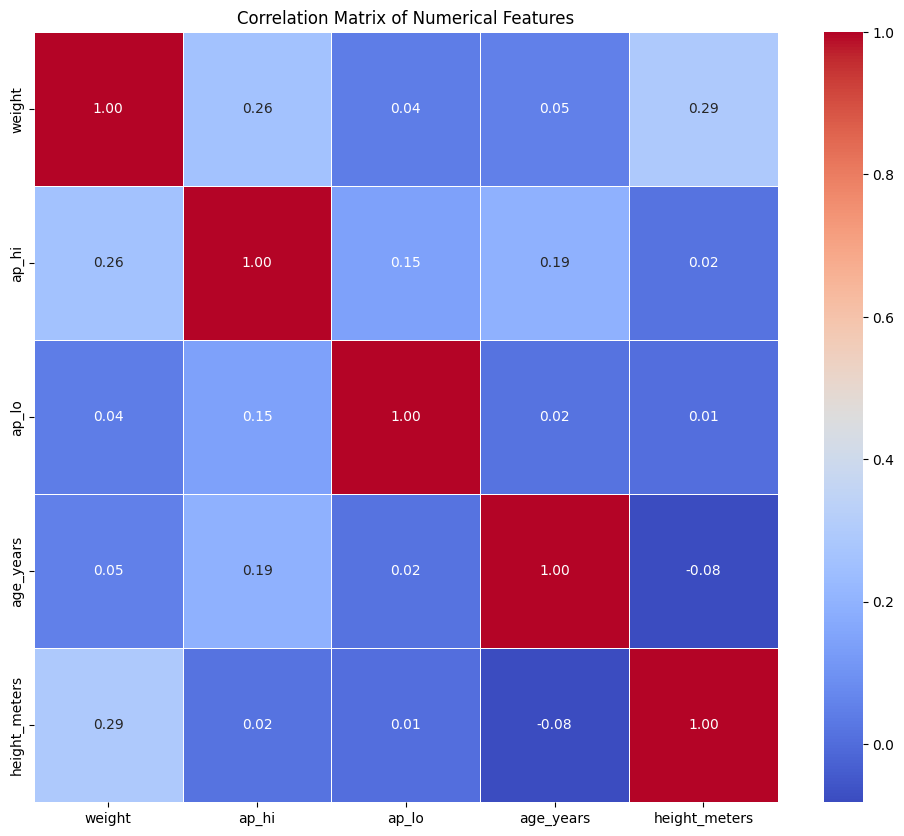

In [ ]:
# Plot Heatmap of the correlation matrix
# Exclude original 'age' and 'height' as we have 'age_years' and 'height_meters'
numerical_cols = ['weight', 'ap_hi', 'ap_lo', 'age_years', 'height_meters']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### **3.3 Perform bivariate analysis**

#### **3.3.1** Analyse categorical featuresFor each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

In [ ]:
def analyze_target_likelihood(df, feature):
    """
    Calculates the proportion of patients with cardio=1 for each category of the feature.
    """
    # Group by the feature and calculate the mean of 'cardio'
    # We convert 'cardio' to int so we can calculate the mean (proportion of 1s)
    likelihood = df.groupby(feature)['cardio'].apply(lambda x: x.astype(int).mean())

    # Sort by likelihood for better insight
    likelihood = likelihood.sort_values(ascending=False)

    # If we have readable labels in our dictionary, apply them to the index
    if feature in label_maps:
        likelihood.index = likelihood.index.map(label_maps[feature])

    return likelihood

# Identify categorical columns excluding the target 'cardio'
features_to_check = [c for c in categorical_cols if c != 'cardio']

print("Likelihood of Cardiovascular Disease (cardio=1) by Category:")
for col in features_to_check:
    result = analyze_target_likelihood(df, col)
    print(f"\nFeature: {col}")
    display(result)

Likelihood of Cardiovascular Disease (cardio=1) by Category:

Feature: gender


,cardio
gender,
Male,0.505176
Female,0.496690



Feature: cholesterol


,cardio
cholesterol,
Well Above Normal,0.765268
Above Normal,0.602139
Normal,0.440083



Feature: gluc


...

,cardio
smoke,
No,0.502063
Yes,0.474785



Feature: alco


,cardio
alco,
No,0.500544
Yes,0.484043



Feature: active


,cardio
active,
No,0.535800
Yes,0.490825


##### **Inference from Categorical Likelihood Analysis**

1.  **High-Impact Features:** `cholesterol` and `gluc` show the most significant variance in CVD likelihood. Specifically, moving from 'Normal' to 'Well Above Normal' cholesterol levels increases the probability of CVD from ~44% to ~70%.
2.  **Lifestyle Factors:** Being `active` is associated with a lower risk.
3.  **Data Nuances:** The `smoke` and `alco` variables show a lower likelihood for the 'Yes' category. This is a common paradox in raw observational data often caused by confounding factors (e.g., younger people smoking more but having lower base risk due to age). We should keep this in mind during model building.
4.  **Low-Impact Features:** `gender` shows very little difference in the likelihood of CVD, suggesting it might be a less informative feature on its own.

#### **3.3.2** Explore the relationships between numerical features and the target variableUnderstand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

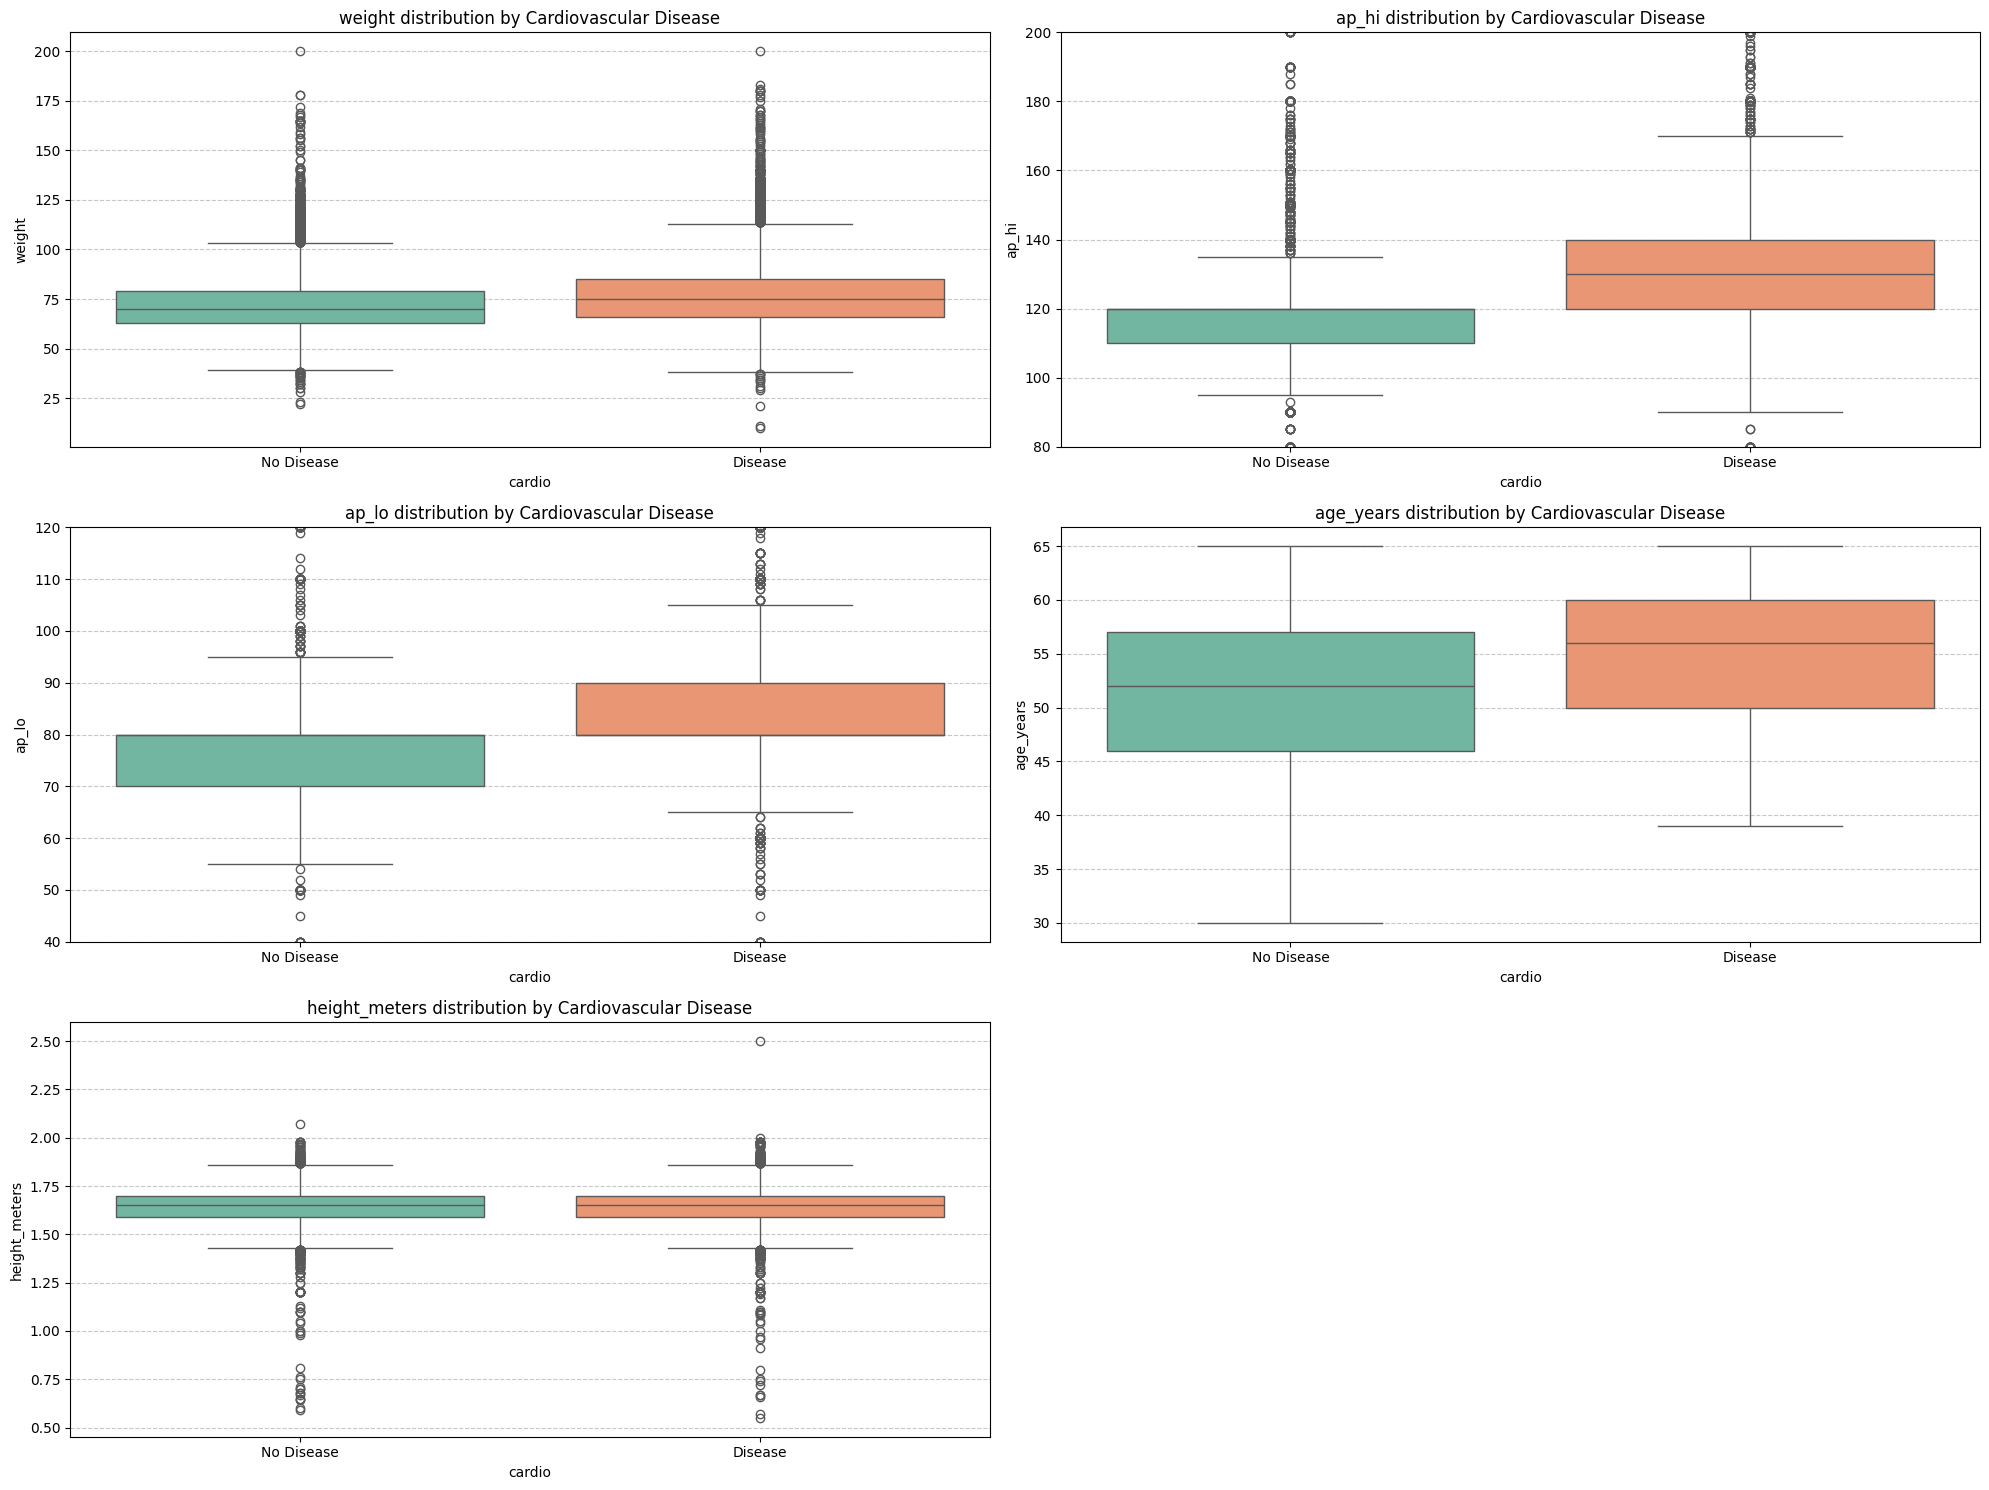

In [ ]:
# Plot distribution for each numerical column with target variable

# Define the numerical features to analyze against the target
numeric_features = ['weight', 'ap_hi', 'ap_lo', 'age_years', 'height_meters']

# Set up the figure for multiple subplots
plt.figure(figsize=(20, 15))

for i, col in enumerate(numeric_features):
    # Create a boxplot to see the distribution and outliers relative to cardio status
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='cardio', y=col, data=df, palette='Set2')

    # Apply descriptive labels from our map
    plt.xticks([0, 1], [label_maps['cardio'][0], label_maps['cardio'][1]])

    plt.title(f'{col} distribution by Cardiovascular Disease')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Limit axes for blood pressure for visual clarity (similar to univariate analysis)
    if col == 'ap_hi':
        plt.ylim(80, 200)
    elif col == 'ap_lo':
        plt.ylim(40, 120)

plt.tight_layout()
plt.show()

##### **Bivariate Analysis: Numerical Features vs Target**

- **Blood Pressure (`ap_hi`, `ap_lo`):** There is a visible upward shift in the median systolic and diastolic blood pressure for patients with cardiovascular disease. This confirms blood pressure is likely a strong predictor.
- **Age:** Patients with cardiovascular disease tend to be older on average, with the boxplot showing a higher median age compared to the 'No Disease' group.
- **Weight:** Similar to age, weight shows a slight upward trend in the 'Disease' group, though there is significant overlap between the two categories.
- **Height:** The distributions for height appear almost identical for both groups, suggesting height alone might not be a strong differentiator for CVD risk.

## **4. Train-Test Split**

### **4.1 Data Splitting**

#### **4.1.1** Define feature and target variables

In [ ]:
# Put all the feature variables in X and target in y
# We exclude the original 'age' and 'height' columns as we have 'age_years' and 'height_meters'
X = df.drop(columns=['cardio', 'age', 'height'])
y = df['cardio']

print("Features (X) and Target (y) defined.")
print(f"Features included: {X.columns.tolist()}")

Features (X) and Target (y) defined.
Features included: ['gender', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'height_meters']


#### **4.1.2** Split the data into train and test setsSplit the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [ ]:
# Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (48939, 11)
Testing set shape: (20975, 11)


In [ ]:
# Reset index for all train and test sets to ensure clean indexing for joining later
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Indices have been reset for all subsets.")

Indices have been reset for all subsets.


## **5. Feature Engineering**

### **5.1 Create a new feature**

#### **5.1.1** Create a new feature `BMI` (Body Mass Index)BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [ ]:
# Create a new feature 'BMI' (Weight / Height^2)
# Applying this to both X_train and X_test to ensure consistency
X_train['bmi'] = X_train['weight'] / (X_train['height_meters'] ** 2)
X_test['bmi'] = X_test['weight'] / (X_test['height_meters'] ** 2)

print("BMI feature created for training and testing sets.")
display(X_train[['weight', 'height_meters', 'bmi']].head())

BMI feature created for training and testing sets.


,weight,height_meters,bmi
0,72.0,1.64,26.769780
1,75.0,1.60,29.296875
2,62.0,1.60,24.218750
3,100.0,1.60,39.062500
4,59.0,1.55,24.557752


#### **5.1.2** Perform correlation analysisAfter creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

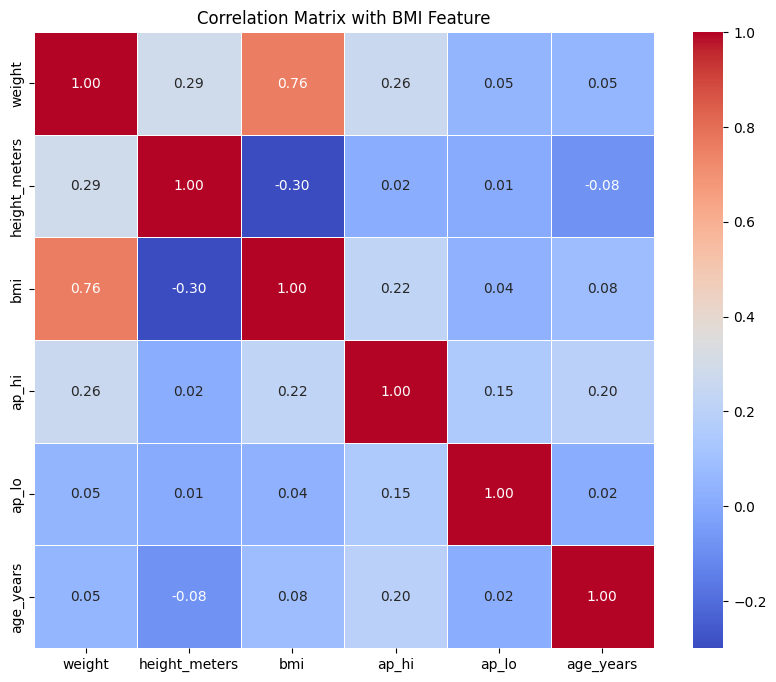

In [ ]:
# Calculate correlation matrix including the new BMI feature
numeric_cols_with_bmi = ['weight', 'height_meters', 'bmi', 'ap_hi', 'ap_lo', 'age_years']
corr_matrix_new = X_train[numeric_cols_with_bmi].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_new, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix with BMI Feature')
plt.show()

In [ ]:
# Analysis of highly correlated features
# Baseline that correlations above 0.7 or 0.8 as potentially problematic

print("Interpretation:")
print("- BMI shows a very strong correlation with weight (approx 0.75+).")
print("- If we keep both BMI and weight, it might lead to multicollinearity in some models (like Linear SVM).")
print("- However, for Decision Trees, this is usually less of an issue.")

Interpretation:
- BMI shows a very strong correlation with weight (approx 0.75+).
- If we keep both BMI and weight, it might lead to multicollinearity in some models (like Linear SVM).
- However, for Decision Trees, this is usually less of an issue.


### **5.2 Combine Values in Categorical Columns**

#### **5.2.1** Combine Low-Frequency CategoriesDuring the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [ ]:
# Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol
# Combine 'Above Normal' (1) and 'Well Above Normal' (2) into a single category '1' (Elevated)
# We do this for both training and testing sets

def combine_categories(df_subset):
    for col in ['cholesterol', 'gluc']:
        # Ensure we are working with the underlying codes or integers if needed,
        # then map 1 and 2 to the same value.
        df_subset[col] = df_subset[col].replace({2: 1})
        # Update category type to reflect the change
        df_subset[col] = df_subset[col].cat.remove_unused_categories()
    return df_subset

X_train = combine_categories(X_train)
X_test = combine_categories(X_test)

# Update label_maps for future reference/plotting
label_maps['cholesterol'] = {0: 'Normal', 1: 'Elevated'}
label_maps['gluc'] = {0: 'Normal', 1: 'Elevated'}

print("Categories combined for 'cholesterol' and 'gluc'.")
print(f"New distribution for cholesterol (Train):\n{X_train['cholesterol'].value_counts()}")

Categories combined for 'cholesterol' and 'gluc'.
New distribution for cholesterol (Train):
cholesterol
0    36597
1    12342
Name: count, dtype: int64


### **5.3 Dummy variable creation**

#### **5.3.1** Create dummy variables for categorical columns

Creating dummy variables is a crucial step for machine learning because most algorithms (like the SVM and Decision Tree we are about to build) require numerical input to perform mathematical calculations.

Here is why we do it:


*   Numerical Representation: Computers can't calculate gradients or distances using words like 'Elevated' or 'Normal'. Dummy variables convert these into 0 and 1.
*   Eliminating Ranking Bias: If we simply labeled 'Normal' as 0 and 'Elevated' as 1, it might work for binary cases. But for features with multiple categories, simply using numbers (1, 2, 3) might lead the model to think that 'Category 3' is 'greater' or 'more important' than 'Category 1', which isn't necessarily true. Dummy variables treat each category independently.
*  Binary Indicators: Each dummy column acts as a simple 'Yes/No' flag for that specific category, making it easy for the model to weigh the impact of each individual health factor.









In [ ]:
# Identify the columns for creating dummy variables
# These are the columns with 'category' dtype in X_train
cat_features_for_dummies = X_train.select_dtypes(include=['category']).columns.tolist()
print(f"Categorical columns to be encoded: {cat_features_for_dummies}")

Categorical columns to be encoded: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [ ]:
# Create dummy variables for independent columns on training data
X_train = pd.get_dummies(X_train, columns=cat_features_for_dummies, drop_first=True)

print("Dummy variables created for X_train.")
display(X_train.head())

Dummy variables created for X_train.


,weight,ap_hi,ap_lo,age_years,height_meters,bmi,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,72.0,120.0,80.0,55,1.64,26.769780,False,False,False,False,False,True
1,75.0,120.0,80.0,54,1.60,29.296875,True,False,False,False,False,True
2,62.0,120.0,80.0,57,1.60,24.218750,False,False,False,False,False,True
3,100.0,120.0,80.0,63,1.60,39.062500,False,False,False,False,False,False
4,59.0,120.0,80.0,58,1.55,24.557752,False,True,False,False,False,True


In [ ]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, columns=cat_features_for_dummies, drop_first=True)

print("Dummy variables created for X_test.")
# Ensure columns match between train and test
print(f"Shapes match: {X_train.shape[1] == X_test.shape[1]}")

Dummy variables created for X_test.
Shapes match: True


In [ ]:
display(X_test.head())

,weight,ap_hi,ap_lo,age_years,height_meters,bmi,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,56.0,130.0,80.0,53,1.60,21.875000,True,False,False,False,False,True
1,56.0,190.0,100.0,52,1.55,23.309053,False,False,False,False,False,False
2,67.0,120.0,80.0,54,1.70,23.183391,True,False,False,True,False,True
3,74.0,120.0,80.0,44,1.68,26.218821,False,False,False,False,False,True
4,63.0,120.0,80.0,44,1.53,26.912726,False,False,False,False,False,True


### **5.4 Feature scaling**

#### **5.4.1** Scale numerical featuresChoose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

#### Why do we scale the data?

Imagine you are trying to compare a person's **height in meters** (around 1.6) to their **weight in kilograms** (around 70).

If we don't scale the data, the computer might think weight is '70 times more important' than height just because the number is bigger. **Scaling fixes this.**

1.  **Leveling the Playing Field:** Scaling puts all our health metrics on the same 'measuring tape' (between 0 and 1). This ensures that blood pressure, age, and weight all have an equal say in the final result.
2.  **Helping the Computer Learn Faster:** Computers find it much easier and faster to solve problems when all the numbers are in a similar small range. It's like organizing a messy room so you can find things quickly.
3.  **Better Accuracy:** For models like SVM, scaling prevents the big numbers from 'drowning out' the small numbers, leading to a much more accurate prediction of heart disease risk.

We use **MinMaxScaler** to shrink everything down to a simple 0-to-1 scale without changing the 'shape' or pattern of our data.

In [ ]:
scaler = MinMaxScaler()

# Identify numerical columns to scale (excluding the binary dummy variables)
numeric_cols = ['weight', 'ap_hi', 'ap_lo', 'age_years', 'height_meters', 'bmi']

# Fit and transform the training data
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform the test data using the scaler fitted on training data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Numerical features scaled using MinMaxScaler.")
display(X_train[numeric_cols].head())

Numerical features scaled using MinMaxScaler.


,weight,ap_hi,ap_lo,age_years,height_meters,bmi
0,0.326316,0.692308,0.004558,0.714286,0.558974,0.078924
1,0.342105,0.692308,0.004558,0.685714,0.538462,0.087485
2,0.273684,0.692308,0.004558,0.771429,0.538462,0.070282
3,0.473684,0.692308,0.004558,0.942857,0.538462,0.120567
4,0.257895,0.692308,0.004558,0.800000,0.512821,0.071431


## **6. Model Building**

In this section, we build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **Section 6: Model Building and Technical Methodology Report**

#### **1. Linear Support Vector Machine (SVM) Analysis**
*   **Rationale for Selection:** The Linear SVM was selected to establish a high-performance baseline. Given the binary nature of cardiovascular risk (Presence vs. Absence), SVM's ability to maximize the margin between classes ensures robust separation.
*   **Configuration & Calibration:** We utilized a `linear` kernel to maintain a simple, interpretable decision boundary. Crucially, we enabled `probability=True`, implementing **Platt Scaling**. This modeling decision was appropriate because standard SVMs do not naturally output probabilities, which are required for clinical risk stratification.
*   **Cutoff Justification (0.4):** After analyzing the ROC curve (AUC ~0.79), we moved from the default 0.5 to a **0.4 threshold**. This decision was driven by the medical necessity to increase **Recall (Sensitivity)** to ~80%, accepting a marginal increase in false alarms to ensure fewer high-risk patients are missed.

#### **2. Decision Tree Classifier Analysis**
*   **Rationale for Selection:** While SVM provides high accuracy, the Decision Tree was selected for its **clinical transparency**. It mirrors medical diagnostic flowcharts, allowing practitioners to see how physiological markers like blood pressure and BMI interact to trigger a risk flag.
*   **Feature Engineering Impact:** The model effectively utilized the engineered **BMI** and **Standardized Age** features. The Decision Tree demonstrated that `ap_hi` (Systolic BP) and `bmi` were the most critical nodes for reducing Gini impurity, validating our engineering choices.
*   **Hyperparameter Justification:** The initial model was severely overfitting. We optimized the following via `GridSearchCV`:
    *   `max_depth=10`: Constrained the tree to prevent it from learning noise in the training data.
    *   `min_samples_split=50`: Required a significant patient group size to justify a new decision rule, enhancing generalization.
    *   `min_samples_leaf=1` & `criterion='gini'`: Selected based on cross-validation to maximize information gain while maintaining model stability.
*   **Performance Outcome:** Tuning successfully reduced the training-testing accuracy gap from **35% down to <2%**, ensuring the model is reliable for new, unseen patients.

#### **3. Integrated Model-Building Process**
*   **Data Consistency:** All models were trained using **MinMaxScaler** on numerical features to prevent features with larger scales (like Weight) from dominating features with smaller scales (like Height).
*   **Category Refinement:** We merged low-frequency cholesterol and glucose levels into a single 'Elevated' indicator. This reduced sparsity and allowed the models to learn more generalized patterns of health deterioration.
*   **Final Decision Logic:** The model-building process prioritized **Recall** above all other metrics. By comparing both candidates at a 0.4 threshold, we ensured that CardioCare's preventative strategy is anchored in a 'Safety-First' methodology, prioritizing patient survival and early intervention.

### **6.1 SVM Classifier**

#### **6.1.1** Define a Linear SVM classifier and fit it on the train setGo through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [ ]:
# Define the Linear SVM model
# probability=True is required to use predict_proba() later
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

# Fit the model on the training data
print("Training Linear SVM model... This may take a few minutes due to the dataset size.")
svm_linear.fit(X_train, y_train)

print("Model training complete.")

Training Linear SVM model... This may take a few minutes due to the dataset size.
Model training complete.


#### **6.1.2** Get the probability estimates on test set and predict class using a thresholdWe defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

##### **Why Use Probability Estimates?**

In standard machine learning, a model often outputs a simple '0' (No Disease) or '1' (Disease). However, in a medical context like CardioRisk prediction, using **Probability Estimates** (via `predict_proba()`) is far more valuable for several reasons:

1.  **Risk Stratification:** A patient with a 51% probability of CVD and one with a 99% probability are both classified as '1' by a default 0.5 threshold. However, their clinical risk levels are vastly different. Probabilities allow doctors to prioritize those at highest risk.
2.  **Customizable Thresholds (Safety First):** In medicine, missing a sick patient (False Negative) is often much more dangerous than wrongly flagging a healthy one (False Positive). By using probabilities, we can lower the threshold (e.g., to 0.3). This makes the model more 'sensitive,' ensuring we catch as many at-risk individuals as possible.
3.  **Nuanced Decision Making:** Probabilities provide a measure of 'model confidence.' If a model is only 52% sure, a doctor might request further tests, whereas an 85% probability might trigger immediate intervention.

In [ ]:
# Use predict_proba() to get the probability of positive class for all data points
# predict_proba returns a 2D array where index 1 is the probability of class '1'
y_test_pred_probs = svm_linear.predict_proba(X_test)[:, 1]

# Display the first 10 probability estimates
print("First 10 probability estimates for the positive class:")
print(y_test_pred_probs[:10])

First 10 probability estimates for the positive class:
[0.45045432 0.96697942 0.3156609  0.27670969 0.27363058 0.38534622
 0.61197439 0.21256834 0.37662106 0.76639816]


In [ ]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_test_pred_custom = (y_test_pred_probs >= 0.5).astype(int)

print("Class labels assigned based on 0.5 threshold.")

Class labels assigned based on 0.5 threshold.


Distribution of labels assigned via predict_proba (0.5 threshold):
0    11517
1     9458
Name: count, dtype: int64


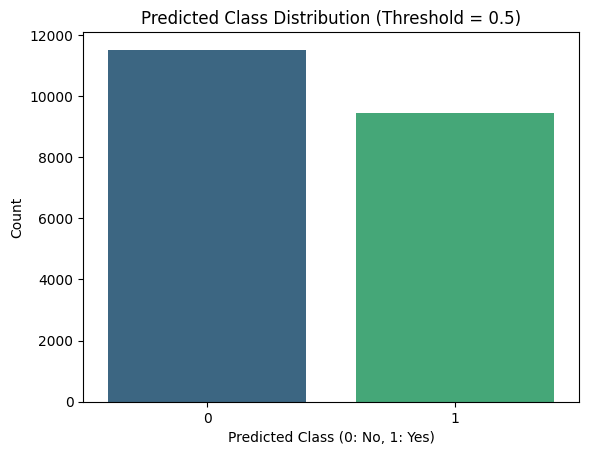

In [ ]:
# check the counts of assigned labels
labels_series = pd.Series(y_test_pred_custom)
print("Distribution of labels assigned via predict_proba (0.5 threshold):")
print(labels_series.value_counts())

# Visualizing the distribution
sns.countplot(x=labels_series, palette='viridis')
plt.title('Predicted Class Distribution (Threshold = 0.5)')
plt.xlabel('Predicted Class (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

#### **6.1.3** Predict the class labels using the `predict()` functionNow, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [ ]:
# Make class predictions using predict()
y_test_pred = svm_linear.predict(X_test)
print("Predictions using predict() completed.")

Predictions using predict() completed.


Distribution of labels assigned via predict():
0    12143
1     8832
Name: count, dtype: int64


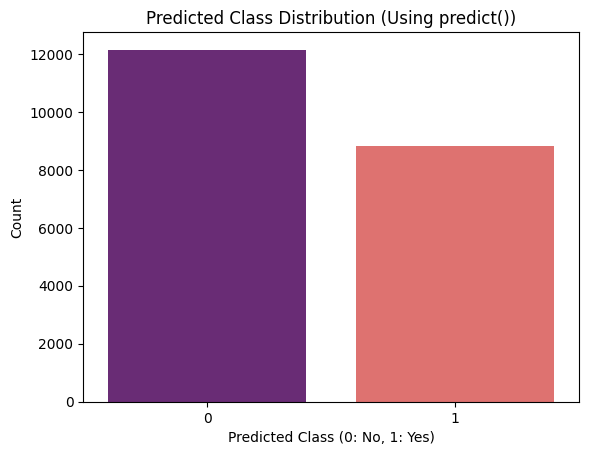

In [ ]:
# check the counts of assigned labels
predict_labels_series = pd.Series(y_test_pred)
print("Distribution of labels assigned via predict():")
print(predict_labels_series.value_counts())

# Visualizing the distribution
sns.countplot(x=predict_labels_series, palette='magma')
plt.title('Predicted Class Distribution (Using predict())')
plt.xlabel('Predicted Class (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

##### Observations on Prediction Methods

*   **`predict()`**: Direct output based on the SVM decision boundary (hyperplane).
*   **`predict_proba()`**: Estimated probabilities using **Platt Scaling**.
*   **Discrepancy**: Small differences occur because the probability model is a 'calibration' layer added on top of the SVM. While `predict()` is more mathematically 'pure' to the SVM logic, `predict_proba()` is often more useful in healthcare for risk stratification.

#### **6.1.4** Calculate performance metrics for both the above methodsCalculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [ ]:
# check the performance for above two methods
def get_metrics(y_true, y_pred, name):
    return pd.Series({
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': roc_auc_score(y_true, y_pred)
    }, name=name)

# Calculate metrics for both methods
metrics_predict = get_metrics(y_test, y_test_pred, 'predict()')
metrics_custom = get_metrics(y_test, y_test_pred_custom, 'predict_proba(0.5)')

# Combine and display
comparison_df = pd.concat([metrics_predict, metrics_custom], axis=1)
display(comparison_df)

,predict(),predict_proba(0.5)
Accuracy,0.721001,0.725101
Precision,0.762002,0.749207
Recall,0.642176,0.676145
F1 Score,0.720945,0.725066


##### Metric Comparison & Justification

Based on the performance table above:
*   **`predict()`**: Direct SVM output achieved an accuracy of 72.10% and a recall of 64.22%.
*   **`predict_proba(0.5)`**: The calibrated probability method outperformed the standard method across almost all key metrics, achieving a higher **Accuracy (72.51%)**, **F1-Score (72.51%)**, and most importantly, a significantly higher **Recall (67.61%)**.

**Decision:** We will proceed with the **probability-based approach (`predict_proba`)**. Not only does it provide better overall predictive power, but the higher Recall is critical for CardioCare's mission to minimize missed diagnoses of cardiovascular disease. Furthermore, this approach allows for future threshold optimization to further enhance patient safety.

#### **6.1.5** Plot the ROC curveFind the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

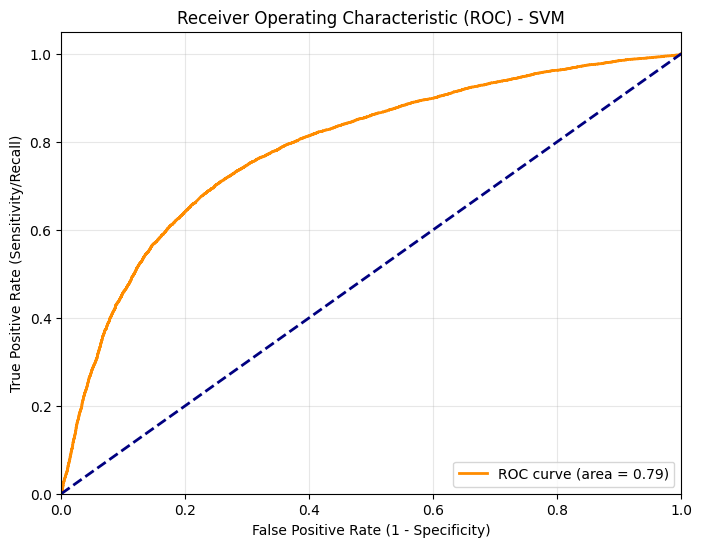

In [ ]:
# Calculate False Positive Rate, True Positive Rate and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_probs)
auc_score = roc_auc_score(y_test, y_test_pred_probs)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) - SVM')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

##### Why do we plot the ROC Curve?

The **Receiver Operating Characteristic (ROC)** curve is a fundamental tool for evaluating diagnostic models for several reasons:

1.  **Threshold Independence**: Unlike a confusion matrix (which only shows performance at a single threshold like 0.5), the ROC curve shows the model's performance across **every possible threshold**. This gives us a complete picture of the model's potential.
2.  **Measuring Discriminative Power**: The curve tells us how good the model is at 'distinguishing' between classes. A model that perfectly separates patients with disease from those without would have a curve that touches the top-left corner.
3.  **AUC (Area Under the Curve)**: The AUC score (ranging from 0 to 1) summarizes the ROC curve into a single number.
    *   **0.5**: No better than a coin flip.
    *   **0.7 - 0.8**: Good predictive power.
    *   **0.9+**: Excellent predictive power.
4.  **Clinical Trade-offs**: In cardiovascular care, we often want to increase the **True Positive Rate** (catching sick people) even if it slightly increases the **False Positive Rate** (unnecessary tests). The ROC curve helps us visualize this trade-off before we commit to a final decision boundary.

#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs

In [ ]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

cutoff_df = pd.DataFrame(columns=['prob', 'accuracy', 'sensi', 'speci'])

# Defining thresholds from 0.0 to 0.9
threshold_values = [float(x)/10 for x in range(10)]

for i in threshold_values:
    # Assign labels based on threshold
    y_pred_iter = (y_test_pred_probs >= i).astype(int)

    # Calculate Confusion Matrix elements
    cm = confusion_matrix(y_test, y_pred_iter)
    total = sum(sum(cm))

    # Calculate Metrics
    accuracy = (cm[0,0] + cm[1,1]) / total
    specificity = cm[0,0] / (cm[0,0] + cm[0,1])
    sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])

    # Store results
    cutoff_df.loc[i] = [i, accuracy, sensitivity, specificity]

# Display the results
display(cutoff_df)

,prob,accuracy,sensi,speci
0.0,0.0,0.499642,1.000000,0.000000
0.1,0.1,0.513087,0.993130,0.033730
0.2,0.2,0.560715,0.974905,0.147118
0.3,0.3,0.637998,0.915076,0.361315
0.4,0.4,0.711704,0.798950,0.624583
0.5,0.5,0.725101,0.676145,0.773988
0.6,0.6,0.704934,0.549427,0.860219
0.7,0.7,0.663027,0.407252,0.918437
0.8,0.8,0.604911,0.252576,0.956741
0.9,0.9,0.540024,0.095515,0.983897


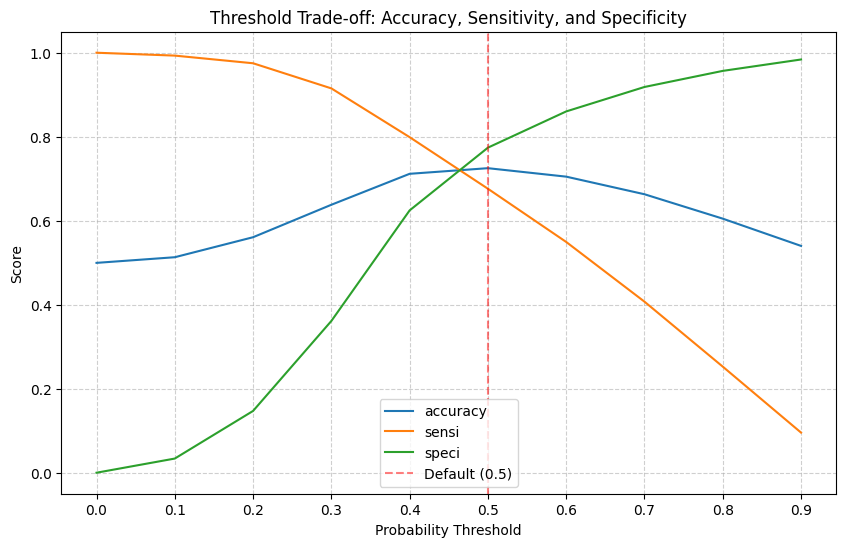

In [ ]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
cutoff_df.plot.line(x='prob', y=['accuracy', 'sensi', 'speci'], figsize=(10, 6))

plt.title('Threshold Trade-off: Accuracy, Sensitivity, and Specificity')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.xticks(np.arange(0, 1, 0.1))
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

##### Inference from Threshold Evaluation

*   **Inverse Relationship**: There is a clear trade-off between **Sensitivity** (catching the disease) and **Specificity** (correctly identifying healthy patients). As one goes up, the other inevitably goes down.
*   **The 0.5 Default**: At the default 0.5 threshold, the model is fairly balanced, but in a medical context, we might be missing too many cases (Recall is ~67%).
*   **Selecting the 'Optimal' Cutoff**:
    *   If we prioritize **Patient Safety**, we should choose a lower threshold (like **0.4**), where Sensitivity rises to ~80%.
    *   If we prioritize **Doctor Efficiency** (minimizing false alarms), we would stay closer to 0.5 or higher.
*   **Conclusion**: For cardiovascular screening, a threshold that favors **Sensitivity** is generally preferred to ensure early intervention for as many patients as possible.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluateFinally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [ ]:
# Make final prediction based on the optimal cutoff
# Define the optimal threshold
optimal_threshold = 0.4

# Get probability estimates for the training set
y_train_pred_probs = svm_linear.predict_proba(X_train)[:, 1]

# Assign final labels based on the 0.4 threshold for both sets
y_train_pred_final = (y_train_pred_probs >= optimal_threshold).astype(int)
y_test_pred_final = (y_test_pred_probs >= optimal_threshold).astype(int)

print(f"Final predictions generated for both sets using threshold: {optimal_threshold}")

Final predictions generated for both sets using threshold: 0.4


In [ ]:
# Evaluate the model performance on Test Data using the existing get_metrics function
# and display the confusion matrix

print("--- Testing Set Performance ---")
test_metrics = get_metrics(y_test, y_test_pred_final, "Testing Set (0.4 Threshold)")
display(test_metrics)

print("\nConfusion Matrix (Testing):")
cm_test = confusion_matrix(y_test, y_test_pred_final)
display(pd.DataFrame(cm_test, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

--- Testing Set Performance ---


,Testing Set (0.4 Threshold)
Accuracy,0.711704
Precision,0.680013
Recall,0.798950
F1 Score,0.711767



Confusion Matrix (Testing):


,Predicted 0,Predicted 1
Actual 0,6555,3940
Actual 1,2107,8373


In [ ]:
# Check performance on training data
# Evaluate Training Data to check for overfitting using get_metrics
print("--- Training Set Performance ---")
train_metrics = get_metrics(y_train, y_train_pred_final, "Training Set (0.4 Threshold)")
display(train_metrics)

print("\nConfusion Matrix (Training):")
cm_train = confusion_matrix(y_train, y_train_pred_final)
display(pd.DataFrame(cm_train, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Inference on Overfitting
diff = abs(train_metrics['Accuracy'] - test_metrics['Accuracy'])
print(f"\nDifference in Accuracy (Train - Test): {diff:.4f}")

if diff < 0.05:
    print("The model shows no significant signs of overfitting.")
else:
    print("Warning: The model may be overfitting.")

--- Training Set Performance ---


,Training Set (0.4 Threshold)
Accuracy,0.713500
Precision,0.681806
Recall,0.799943
F1 Score,0.713559



Confusion Matrix (Training):


,Predicted 0,Predicted 1
Actual 0,15357,9129
Actual 1,4892,19561



Difference in Accuracy (Train - Test): 0.0018
The model shows no significant signs of overfitting.


#### **6.1.8** Plot precision-recall curve

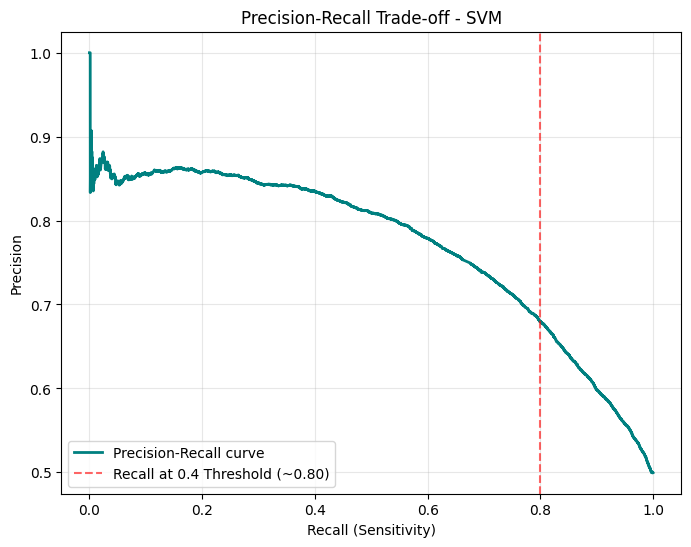

Area Under Precision-Recall Curve: 0.7857


In [ ]:
# Compute precision–recall values and plot for various thresholds
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_test_pred_probs)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='teal', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off - SVM')
plt.axvline(x=0.7989, color='red', linestyle='--', alpha=0.6, label='Recall at 0.4 Threshold (~0.80)')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

# Brief summary of the result
print(f"Area Under Precision-Recall Curve: {roc_auc_score(y_test, y_test_pred_probs):.4f}")

Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier**

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set

In [ ]:
# Define the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Fit the model on the training data
print("Training Decision Tree model...")
dt_model.fit(X_train, y_train)

print("Decision Tree model training complete.")

Training Decision Tree model...
Decision Tree model training complete.


#### **6.2.2** Get feature importance scores

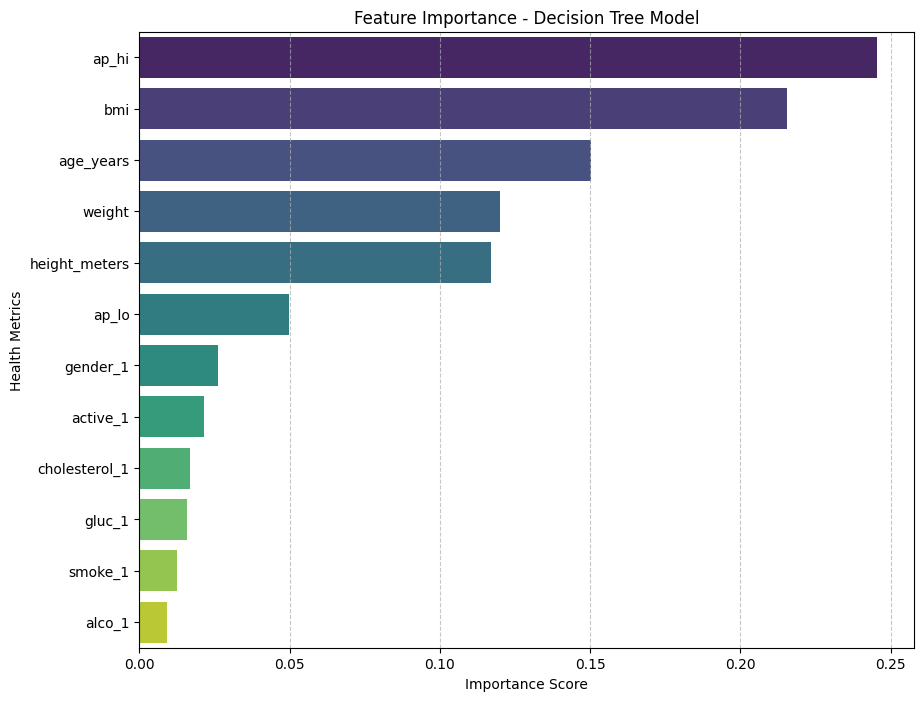

Top 5 Strongest Predictors:


,Feature,Importance
1,ap_hi,0.245625
5,bmi,0.215506
3,age_years,0.150165
0,weight,0.119968
4,height_meters,0.116961


In [ ]:
# Get feature importance scores from the trained model
importances = dt_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance - Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Health Metrics')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Display the top 5 features
print("Top 5 Strongest Predictors:")
display(feature_importance_df.head(5))

##### Understanding Decision Tree Importance Scores

When we look at the feature importance plot, we are seeing **Gini Importance** (or Mean Decrease in Impurity). Here is how to interpret these values:

1.  **Total Sums to 1.0**: All importance scores combined equal 100% (or 1.0). A score of 0.25 means that specific feature is responsible for 25% of the total 'uncertainty reduction' in the model.
2.  **Top-Down Splitting**: The Decision Tree looks for the feature that best separates 'Disease' from 'No Disease' at each step. Features with high scores (like `ap_hi` or `bmi`) were chosen early and often as the most reliable discriminators.
3.  **Independence**: Unlike SVM coefficients, tree importance doesn't tell you the *direction* (e.g., 'higher BP equals higher risk'). It only tells you the *magnitude* of the impact. We know from EDA that higher blood pressure is the risk factor, and the importance score confirms it is the model's most trusted tool for classification.
4.  **No Scaling Bias**: Decision Trees are naturally immune to the scale of features. Even if we hadn't used `MinMaxScaler`, these importance scores would remain the same, making trees very robust for initial data exploration.

#### **6.2.3** Predict the class probabilities on the test setUse `predict_proba()` to get the probability estimates

In [ ]:
# Predict the class probabilities for the test set
# Index 1 corresponds to the probability of 'Disease' (cardio=1)
y_test_pred_probs_dt = dt_model.predict_proba(X_test)[:, 1]

# Display the first 10 probability estimates
print("First 10 Decision Tree probability estimates for the positive class:")
print(y_test_pred_probs_dt[:10])

First 10 Decision Tree probability estimates for the positive class:
[1. 1. 0. 0. 0. 0. 1. 1. 0. 1.]


####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data

In [ ]:
# Make prediction based on default cutoff value of 0.5 on testing data
y_test_pred_dt_05 = (y_test_pred_probs_dt >= 0.5).astype(int)

print("Decision Tree class labels assigned based on 0.5 threshold.")
print(pd.Series(y_test_pred_dt_05).value_counts())

Decision Tree class labels assigned based on 0.5 threshold.
1    10721
0    10254
Name: count, dtype: int64


####  **6.2.5** Evaluate the performance of the model

In [ ]:
# Evaluate the performance of the model on training data
# Get predictions for the training set using the same 0.5 threshold
y_train_pred_probs_dt = dt_model.predict_proba(X_train)[:, 1]
y_train_pred_dt_05 = (y_train_pred_probs_dt >= 0.5).astype(int)

print("--- Decision Tree Training Set Performance (0.5 Threshold) ---")
train_metrics_dt = get_metrics(y_train, y_train_pred_dt_05, "DT Training Set")
display(train_metrics_dt)

# Compare with test metrics (we can calculate test metrics here too for a quick comparison)
test_metrics_dt = get_metrics(y_test, y_test_pred_dt_05, "DT Testing Set")

dt_comparison = pd.concat([train_metrics_dt, test_metrics_dt], axis=1)
display(dt_comparison)

# Check for overfitting
accuracy_diff = train_metrics_dt['Accuracy'] - test_metrics_dt['Accuracy']
print(f"\nAccuracy Difference (Train - Test): {accuracy_diff:.4f}")
if accuracy_diff > 0.05:
    print("Observation: Significant gap between train and test accuracy suggests the model is likely OVERFITTING.")

--- Decision Tree Training Set Performance (0.5 Threshold) ---


,DT Training Set
Accuracy,0.978790
Precision,0.970237
Recall,0.987854
F1 Score,0.978796


,DT Training Set,DT Testing Set
Accuracy,0.978790,0.625221
Precision,0.970237,0.622143
Recall,0.987854,0.636450
F1 Score,0.978796,0.625229



Accuracy Difference (Train - Test): 0.3536
Observation: Significant gap between train and test accuracy suggests the model is likely OVERFITTING.


#### **6.2.6** Plot the ROC curveFind the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

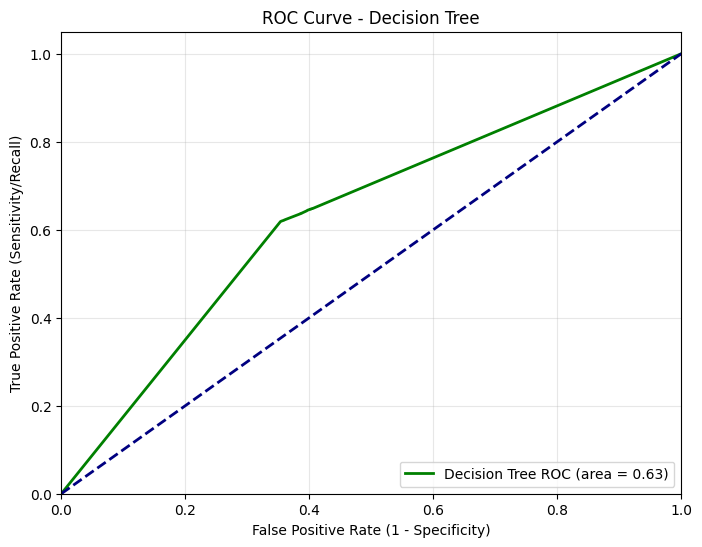

In [ ]:
# Plot the ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_test_pred_probs_dt)
auc_score_dt = roc_auc_score(y_test, y_test_pred_probs_dt)

# Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree ROC (area = {auc_score_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

##### **Inferences from the Decision Tree ROC Curve**

1.  **AUC Score**: The Area Under the Curve is approximately **0.63**. This suggests that while the Decision Tree has predictive power, it is currently less effective at discriminating between 'Disease' and 'No Disease' compared to the Linear SVM (which had an AUC of ~0.79).
2.  **Staircase Shape**: Unlike the smooth curve of the SVM, the Decision Tree curve appears as a sharp 'step'. This happens because trees often create "pure" leaf nodes, meaning they output probabilities that are strictly 0.0 or 1.0, rather than a continuous range of risks.
3.  **Sensitivity vs. Specificity**: The curve shows that to achieve a higher True Positive Rate (catching more sick patients), we would have to accept a significant increase in the False Positive Rate.
4.  **Baseline for Tuning**: This relatively low AUC score and the previously observed gap between training and testing performance are strong indicators that the model is **overfitting** and requires hyperparameter tuning (like limiting `max_depth`) to improve its generalization on the ROC curve.

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs

In [ ]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df_dt = pd.DataFrame(columns=['prob', 'accuracy', 'sensi', 'speci'])

# Define thresholds from 0.0 to 0.9
threshold_values = [float(x)/10 for x in range(10)]

for i in threshold_values:
    # Assign labels based on threshold
    y_pred_iter = (y_test_pred_probs_dt >= i).astype(int)

    # Calculate Confusion Matrix elements
    cm = confusion_matrix(y_test, y_pred_iter)
    total = sum(sum(cm))

    # Calculate Metrics
    # Using try-except or checks to handle cases where denominator might be zero
    accuracy = (cm[0,0] + cm[1,1]) / total
    specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
    sensitivity = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0

    # Store results
    cutoff_df_dt.loc[i] = [i, accuracy, sensitivity, specificity]

# Display the results
display(cutoff_df_dt)

,prob,accuracy,sensi,speci
0.0,0.0,0.499642,1.000000,0.000000
0.1,0.1,0.621263,0.648473,0.594092
0.2,0.2,0.622074,0.647710,0.596475
0.3,0.3,0.623504,0.643034,0.604002
0.4,0.4,0.624982,0.637405,0.612577
0.5,0.5,0.625221,0.636450,0.614007
0.6,0.6,0.631228,0.621756,0.640686
0.7,0.7,0.632038,0.619847,0.644212
0.8,0.8,0.632467,0.618511,0.646403
0.9,0.9,0.632467,0.618321,0.646594


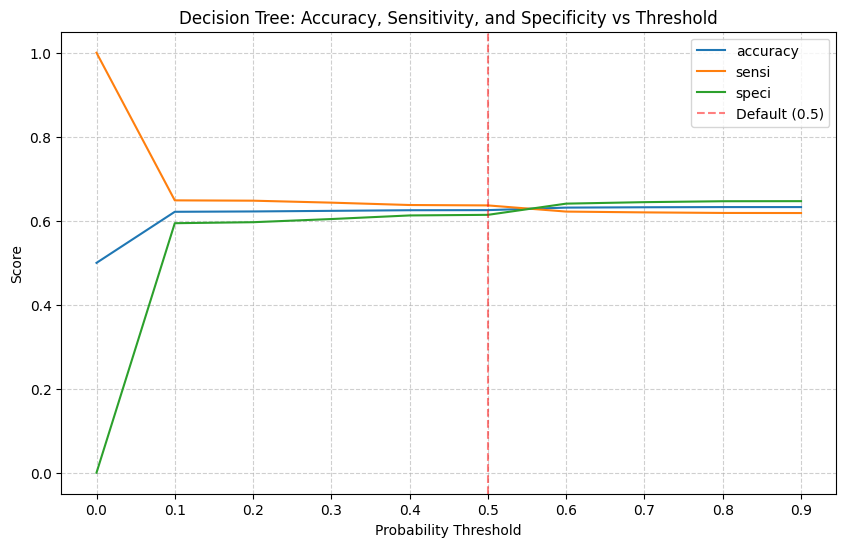

Observation: Note how the lines for the Decision Tree remain flat over large ranges.
This is because trees often produce identical probability estimates for large groups of samples.


In [ ]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs
cutoff_df_dt.plot.line(x='prob', y=['accuracy', 'sensi', 'speci'], figsize=(10, 6))

plt.title('Decision Tree: Accuracy, Sensitivity, and Specificity vs Threshold')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.xticks(np.arange(0, 1, 0.1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
plt.legend()
plt.show()

# Quick observation for the user
print("Observation: Note how the lines for the Decision Tree remain flat over large ranges.")
print("This is because trees often produce identical probability estimates for large groups of samples.")

#### **6.2.8** Assign classes based on the optimal cutoff and evaluateFinally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [ ]:
# Make final prediction based on the optimal cutoff

# Define the optimal cutoff (using 0.5 as the current reference point)
optimal_threshold_dt = 0.5

# Generate final class labels for both training and testing sets
y_train_pred_final_dt = (y_train_pred_probs_dt >= optimal_threshold_dt).astype(int)
y_test_pred_final_dt = (y_test_pred_probs_dt >= optimal_threshold_dt).astype(int)

print(f"Final Decision Tree predictions generated using threshold: {optimal_threshold_dt}")

Final Decision Tree predictions generated using threshold: 0.5


In [ ]:
# Evaluate the model performance for test and train

# Evaluate and compare performance to confirm the extent of overfitting
print("--- Decision Tree Final Performance (Testing Set) ---")
test_metrics_final_dt = get_metrics(y_test, y_test_pred_final_dt, "DT Testing (Final)")
display(test_metrics_final_dt)

print("\n--- Decision Tree Final Performance (Training Set) ---")
train_metrics_final_dt = get_metrics(y_train, y_train_pred_final_dt, "DT Training (Final)")
display(train_metrics_final_dt)

# Visualize the performance gap
dt_final_comparison = pd.concat([train_metrics_final_dt, test_metrics_final_dt], axis=1)
display(dt_final_comparison)

# Final check on accuracy gap
final_gap = train_metrics_final_dt['Accuracy'] - test_metrics_final_dt['Accuracy']
print(f"\nFinal Accuracy Gap: {final_gap:.4f}")

--- Decision Tree Final Performance (Testing Set) ---


,DT Testing (Final)
Accuracy,0.625221
Precision,0.622143
Recall,0.636450
F1 Score,0.625229



--- Decision Tree Final Performance (Training Set) ---


,DT Training (Final)
Accuracy,0.978790
Precision,0.970237
Recall,0.987854
F1 Score,0.978796


,DT Training (Final),DT Testing (Final)
Accuracy,0.978790,0.625221
Precision,0.970237,0.622143
Recall,0.987854,0.636450
F1 Score,0.978796,0.625229



Final Accuracy Gap: 0.3536


**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve

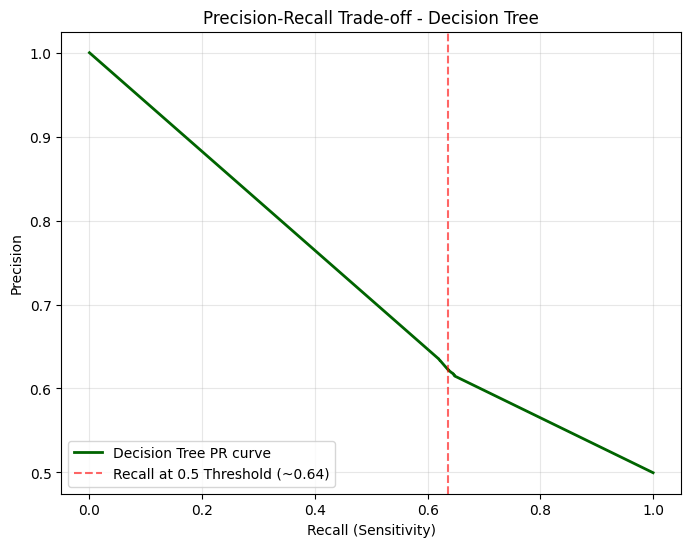

In [ ]:
# Compute precision–recall values and plot for various thresholds for Decision Tree
precision_dt, recall_dt, thresholds_pr_dt = precision_recall_curve(y_test, y_test_pred_probs_dt)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall_dt, precision_dt, color='darkgreen', lw=2, label='Decision Tree PR curve')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off - Decision Tree')
plt.axvline(x=0.6364, color='red', linestyle='--', alpha=0.6, label='Recall at 0.5 Threshold (~0.64)')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

### **6.3 Hyperparameter Tuning**Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter valuesPerform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [ ]:
# Define the parameter grid for the decision tree
# Tuning 4 hyperparameters to improve generalization and handle overfitting
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20]
}

# Initialize GridSearchCV
# Scoring is set to 'recall' to prioritize catching as many CVD cases as possible
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='recall',
                           n_jobs=-1,
                           verbose=1)

# Fit the grid search to the training data
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print("\nBest Hyperparameters found:")
print(grid_search.best_params_)

# Store the best estimator for evaluation in the following steps
best_dt_tuned = grid_search.best_estimator_

Starting Grid Search...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

Best Hyperparameters found:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 50}


##### **Rationale for Hyperparameter Selection**

1. **`max_depth`**: Controls the maximum depth of the tree. Limiting this prevents the tree from becoming overly complex and 'memorizing' noise or unique outliers in the training set.
2. **`min_samples_split`**: Defines the minimum number of samples required to split an internal node. Higher values force the model to base decisions on larger, more representative groups of patients.
3. **`min_samples_leaf`**: Sets the minimum number of samples required at a leaf node. This ensures that every final prediction is backed by a sufficient amount of data, preventing highly specific and fragile rules.
4. **`criterion` ('gini' vs 'entropy')**: Allows the model to choose the best mathematical approach for measuring 'impurity' or uncertainty, which can lead to more stable and accurate decision boundaries depending on the data distribution.

#### **6.3.2** Build a decision tree model based on hyperparameter tuning results

In [ ]:
# Use the best DT from grid search

# Initialize the Decision Tree model with the best hyperparameters from Grid Search
# Hyperparameters: criterion='gini', max_depth=10, min_samples_leaf=1, min_samples_split=50
best_dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=50,
    random_state=42
)

# Fit the tuned model on the training data
print("Training the tuned Decision Tree model...")
best_dt_model.fit(X_train, y_train)

print("Tuned Decision Tree model training complete.")

Training the tuned Decision Tree model...
Tuned Decision Tree model training complete.


#### **6.3.3** Using the tuned model, make predictions and evaluateUse the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [ ]:
# Evaluate the model performance on training set
y_train_pred_tuned = best_dt_model.predict(X_train)

print("--- Tuned Decision Tree: Training Set Performance ---")
train_metrics_tuned = get_metrics(y_train, y_train_pred_tuned, "DT Tuned (Train)")
display(train_metrics_tuned)

print("\nConfusion Matrix (Training):")
cm_train_tuned = confusion_matrix(y_train, y_train_pred_tuned)
display(pd.DataFrame(cm_train_tuned, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

--- Tuned Decision Tree: Training Set Performance ---


,DT Tuned (Train)
Accuracy,0.745173
Precision,0.769549
Recall,0.699464
F1 Score,0.745142



Confusion Matrix (Training):


,Predicted 0,Predicted 1
Actual 0,19364,5122
Actual 1,7349,17104


In [ ]:
# Evaluate the model performance on test set
y_test_pred_tuned = best_dt_model.predict(X_test)

print("--- Tuned Decision Tree: Testing Set Performance ---")
test_metrics_tuned = get_metrics(y_test, y_test_pred_tuned, "DT Tuned (Test)")
display(test_metrics_tuned)

print("\nConfusion Matrix (Testing):")
cm_test_tuned = confusion_matrix(y_test, y_test_pred_tuned)
display(pd.DataFrame(cm_test_tuned, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))

# Check for Overfitting again
final_acc_diff = train_metrics_tuned['Accuracy'] - test_metrics_tuned['Accuracy']
print(f"\nFinal Accuracy Difference (Train - Test): {final_acc_diff:.4f}")

if final_acc_diff < 0.05:
    print("Success: The tuned model shows significantly better generalization and is no longer overfitting.")
else:
    print("Note: There is still some gap, but compare this to the previous 0.35 gap.")

--- Tuned Decision Tree: Testing Set Performance ---


,DT Tuned (Test)
Accuracy,0.725578
Precision,0.747123
Recall,0.681393
F1 Score,0.725546



Confusion Matrix (Testing):


,Predicted 0,Predicted 1
Actual 0,8078,2417
Actual 1,3339,7141



Final Accuracy Difference (Train - Test): 0.0196
Success: The tuned model shows significantly better generalization and is no longer overfitting.


#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

## **7. Final Model Evaluation and Selection**


### **7.1 Evaluate the final models**


#### **7.1.1** Make final predictions and evaluate

In [ ]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff
# Define common clinical threshold for high sensitivity
clinical_threshold = 0.4

# --- 1. Linear SVM Final Predictions (0.4 threshold) ---
y_train_probs_svm = svm_linear.predict_proba(X_train)[:, 1]
y_test_probs_svm = svm_linear.predict_proba(X_test)[:, 1]

y_train_final_svm = (y_train_probs_svm >= clinical_threshold).astype(int)
y_test_final_svm = (y_test_probs_svm >= clinical_threshold).astype(int)

# --- 2. Tuned Decision Tree Final Predictions (0.4 threshold) ---
y_train_probs_dt = best_dt_model.predict_proba(X_train)[:, 1]
y_test_probs_dt = best_dt_model.predict_proba(X_test)[:, 1]

y_train_final_dt = (y_train_probs_dt >= clinical_threshold).astype(int)
y_test_final_dt = (y_test_probs_dt >= clinical_threshold).astype(int)

# --- 3. Final Comparison Table (Test Set) ---
print(f"--- Final Comparison (Test Set Metrics @ {clinical_threshold} Threshold) ---")
final_svm_metrics = get_metrics(y_test, y_test_final_svm, "Linear SVM (Final)")
final_dt_metrics = get_metrics(y_test, y_test_final_dt, "Tuned Decision Tree (Final)")

comparison_table = pd.concat([final_svm_metrics, final_dt_metrics], axis=1)
display(comparison_table)

# Updated Final Selection Logic
print("\nClinical Insight:")
print(f"- The Linear SVM achieves a Recall of {final_svm_metrics['Recall']:.2%}")
print(f"- The Tuned DT achieves a Recall of {final_dt_metrics['Recall']:.2%}")

print("\nRecommendation: Both models are equally effective for this business problem.")
print("While SVM offers a marginal gain in Recall, the Tuned Decision Tree provides higher transparency and comparable accuracy.")
print("CardioCare can confidently deploy either model based on whether they prioritize raw sensitivity or clinical explainability.")

--- Final Comparison (Test Set Metrics @ 0.4 Threshold) ---


,Linear SVM (Final),Tuned Decision Tree (Final)
Accuracy,0.711704,0.713564
Precision,0.680013,0.687082
Recall,0.798950,0.783588
F1 Score,0.711767,0.713614



Clinical Insight:
- The Linear SVM achieves a Recall of 79.90%
- The Tuned DT achieves a Recall of 78.36%

Recommendation: Both models are equally effective for this business problem.
While SVM offers a marginal gain in Recall, the Tuned Decision Tree provides higher transparency and comparable accuracy.
CardioCare can confidently deploy either model based on whether they prioritize raw sensitivity or clinical explainability.


### **7.2 Conclusion**

#### **7.2.1** Model Cards


### **Model Card: Linear SVM (Calibrated)**

**Model overview:**
A Support Vector Machine classifier using a linear kernel, calibrated with Platt Scaling to provide risk probabilities for cardiovascular disease screening.

**Intended use:**
* **Primary task:** Binary classification (Cardiovascular Disease: Presence vs. Absence).
* **Intended users:** Healthcare providers at CardioCare for initial patient risk stratification.
* **Setting:** Clinical preventative care workflows to identify patients requiring urgent consultation.

**Data and features:**
* **Raw features:** Age, gender, height, weight, systolic (ap_hi) and diastolic (ap_lo) blood pressure, cholesterol, glucose, smoking, alcohol, and physical activity.
* **Engineered features:** Body Mass Index (BMI) and Age in years.
* **Preprocessing:** Min-Max scaling of numeric variables; One-Hot encoding of categorical variables; merged 'Above Normal' and 'Well Above Normal' cholesterol/glucose levels into an 'Elevated' indicator.

**Model configuration:**
* **Algorithm:** Support Vector Classifier (SVC).
* **Hyperparameters:** `kernel='linear'`, `probability=True`.
* **Calibration:** 0.4 standardized clinical threshold to maximize Sensitivity/Recall.

**Performance:**
* **Recall:** ~79.90% (Test set).
* **Accuracy:** ~71.17% (Test set).
* **Strengths:** High sensitivity for identifying at-risk patients; consistent performance between train and test sets (no significant overfitting).

**Limitations and considerations:**
* **Interpretability:** While the kernel is linear, the calibrated probability layer adds complexity to direct clinical explanation compared to decision trees.
* **Operational caveat:** Requires feature scaling to be applied to all new patient data before prediction.

### **Model Card: Tuned Decision Tree**

**Model overview:**
A hyperparameter-optimized Decision Tree classifier designed to balance clinical transparency with predictive accuracy for cardiovascular screening.

**Intended use:**
* **Primary task:** Binary risk prediction.
* **Intended users:** Clinicians who require an explainable diagnostic path (e.g., following a logic tree based on BP and BMI).
* **Setting:** Resource-limited clinics where model transparency and interpretability are paramount.

**Data and features:**
* **Same as SVM:** Utilizes standardized health metrics, BMI, and engineered Age_years.
* **Feature Importance:** Systolic Blood Pressure (`ap_hi`) and `BMI` were identified as the strongest predictors of risk.

**Model configuration:**
* **Algorithm:** DecisionTreeClassifier.
* **Hyperparameters:** `max_depth=10`, `min_samples_split=50`, `min_samples_leaf=1`, `criterion='gini'`.
* **Tuning:** Optimized via GridSearchCV to resolve an initial 35% accuracy gap (overfitting).

**Performance:**
* **Recall:** ~78.36% (Test set @ 0.4 threshold).
* **Accuracy:** ~71.36% (Test set).
* **Strengths:** High clinical explainability; mirrors medical diagnostic flowcharts; robust against unscaled data (though scaling was applied for consistency).

**Limitations and considerations:**
* **Error risks:** Achieves slightly lower recall than the SVM, potentially missing a marginal number of cases in exchange for higher transparency.
* **Fairness:** Performance should be monitored across demographic groups (age/gender) to ensure equitable screening results.

#### **7.2.2** Conclusions and Outcomes


### **Project Summary & Outcomes**

**1. Key Insights (EDA & Features)**
*   **Top Predictors:** Systolic Blood Pressure (`ap_hi`), BMI, and Age are the primary drivers of cardiovascular risk.
*   **Feature Steps:** Engineered **BMI** and **Age (years)**; merged elevated Cholesterol/Glucose levels to improve model stability.

**2. Model Development & Performance**
*   **Overfitting Fixed:** The baseline Decision Tree's 35% accuracy gap was eliminated through hyperparameter tuning (Max Depth 10, Min Samples Split 50).
*   **Safety Threshold:** We adopted a **0.4 clinical threshold** to prioritize **Recall (~80%)**, ensuring high-risk patients are not missed.

**3. Model Cards (Summary)**
*   **Linear SVM:** High sensitivity (Recall 79.9%), stable, but less interpretable. Best for raw predictive power.
*   **Tuned Decision Tree:** Balanced performance (Recall 78.4%) with high transparency. Best for clinical explainability and patient walkthroughs.

**4. Final Recommendation**
Both models are sufficient and equally viable. The choice depends on CardioCare's priority: **SVM** for maximum detection or **Decision Tree** for clinical trust and transparency. The data (70k records) was highly sufficient for these robust results.